# EDA Provincial — SC Tenerife
### Climate Mortality Project · Phase 2 

## Objective

Exploratory analysis of the SC Tenerife provincial master dataset.  
Replicates the island-level EDA structure to allow direct effect size comparison (η²).


---

**Data source:** `master_province_sc_tenerife_weekly.parquet`  
**Reference:** `eda_tenerife_insular.ipynb` — η² = 0.054  
**Outputs:** `reports/provinces/tables/` · `reports/provinces/figures/`

# 1. Load Data

In [150]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BASE    = Path(r"C:\Users\fdora\RA_Career\Projects\climate_mortality")
DATA    = BASE / "data/processed/provinces"
TABLES  = BASE / "reports/provinces/tables"
FIGURES = BASE / "reports/provinces/figures"

TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Load ───────────────────────────────────────────────────────────────────
df_tf = pd.read_parquet(DATA / "master_provincial_sc_tenerife_2016_2025.parquet")

print(f"Shape: {df_tf.shape}")
print(f"Date range: {df_tf['week_start'].min()} → {df_tf['week_start'].max()}")
print(f"\nNulls:\n{df_tf.isnull().sum()[df_tf.isnull().sum() > 0]}")

Shape: (522, 10)
Date range: 2016-01-04 00:00:00 → 2025-12-29 00:00:00

Nulls:
Series([], dtype: int64)


In [151]:
print(df_tf.dtypes)
print()
print(df_tf.describe().round(2))

week_start                   datetime64[ns]
province                             object
population                            int64
deaths                                int64
deaths_per_100k                     float64
pop_intense                           int64
pct_exposed                         float64
calima_intensa_provincial              bool
calima_score_provincial             float64
calima_level_provincial              object
dtype: object

                week_start  population  deaths  deaths_per_100k  pop_intense  \
count                  522       522.0  522.00           522.00       522.00   
mean   2020-12-31 12:00:00   1032000.0  162.40            15.74     90568.97   
min    2016-01-04 00:00:00   1032000.0  109.00            10.56         0.00   
25%    2018-07-03 18:00:00   1032000.0  144.00            13.95         0.00   
50%    2020-12-31 12:00:00   1032000.0  160.00            15.50         0.00   
75%    2023-07-01 06:00:00   1032000.0  176.75            17.13  

In [152]:
print(df_tf.columns.tolist())
print(df_tf[['calima_score_provincial', 'calima_level_provincial']].value_counts().head(10))

['week_start', 'province', 'population', 'deaths', 'deaths_per_100k', 'pop_intense', 'pct_exposed', 'calima_intensa_provincial', 'calima_score_provincial', 'calima_level_provincial']
calima_score_provincial  calima_level_provincial
0.000000                 no_calima                  220
0.003553                 no_calima                   82
0.295866                 possible                    24
0.299419                 possible                    14
0.026809                 no_calima                   14
0.030362                 no_calima                   11
0.595284                 probable                    11
0.053618                 no_calima                   10
0.992894                 intense                      9
0.322674                 possible                     8
Name: count, dtype: int64


# 2. Description

In [153]:
# ── Descriptive by calima group ────────────────────────────────────────────
grouped = df_tf.groupby('calima_intensa_provincial')['deaths_per_100k'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std'
).round(3)

grouped.index = ['No intense calima', 'Intense calima']
print(grouped)

delta = grouped.loc['Intense calima', 'mean'] - grouped.loc['No intense calima', 'mean']
print(f"\nΔ mean deaths/100k: {delta:.3f}")

                   count    mean  median    std
No intense calima    473  15.573  15.407  2.375
Intense calima        49  17.313  17.248  2.359

Δ mean deaths/100k: 1.740


# 3. Test  ANOVA

In [154]:
level_order = ['no_calima', 'possible', 'probable', 'intense']

groups = [df_tf[df_tf['calima_level_provincial'] == level]['deaths_per_100k'].dropna()
          for level in level_order]

f_stat, p_value = stats.f_oneway(*groups)

grand_mean = df_tf['deaths_per_100k'].mean()
ss_between = sum(len(groups[i]) * (groups[i].mean() - grand_mean)**2
                 for i in range(len(groups)))
ss_total   = sum((df_tf['deaths_per_100k'] - grand_mean)**2)
eta_squared = ss_between / ss_total

ref_tfe = pd.read_csv('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/tenerife/anova_insular_tfe.csv')
eta_tfe  = ref_tfe.loc[0, 'eta_squared']
f_tfe    = ref_tfe.loc[0, 'f_statistic']



print(f"ANOVA: Deaths/100k across calima levels — SC Tenerife Provincial")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"η²:          {eta_squared:.4f}")
print(f"η² insular TFE: {eta_tfe:.4f}")
print(f"Δ η²:           {eta_squared - eta_tfe:.4f}")

ANOVA: Deaths/100k across calima levels — SC Tenerife Provincial
F-statistic: 10.3077
P-value:     0.000001
η²:          0.0563
η² insular TFE: 0.0541
Δ η²:           0.0023


# 4.Lag analysis

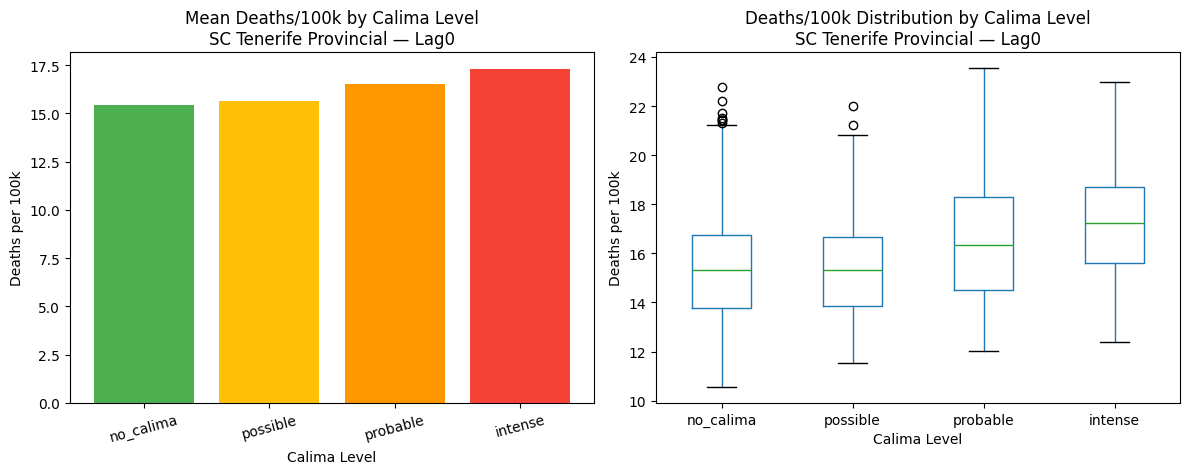

✓ Saved


In [155]:
# ── Figure: deaths/100k by calima level (provincial) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Means by level
means = df_tf.groupby('calima_level_provincial')['deaths_per_100k'].mean().reindex(level_order)

# Left: bar chart
axes[0].bar(level_order, means.values, color=['#4CAF50','#FFC107','#FF9800','#F44336'])
axes[0].set_title('Mean Deaths/100k by Calima Level\nSC Tenerife Provincial — Lag0')
axes[0].set_xlabel('Calima Level')
axes[0].set_ylabel('Deaths per 100k')
axes[0].tick_params(axis='x', rotation=15)

# Right: boxplot
df_plot = df_tf[df_tf['calima_level_provincial'].isin(level_order)].copy()
df_plot['calima_level_provincial'] = pd.Categorical(
    df_plot['calima_level_provincial'], categories=level_order, ordered=True
)
df_plot.boxplot(column='deaths_per_100k', by='calima_level_provincial',
                ax=axes[1], grid=False)
axes[1].set_title('Deaths/100k Distribution by Calima Level\nSC Tenerife Provincial — Lag0')
axes[1].set_xlabel('Calima Level')
axes[1].set_ylabel('Deaths per 100k')
plt.suptitle('')

plt.tight_layout()
plt.savefig(FIGURES / 'deaths_by_calima_level_sc_tenerife_provincial.png', dpi=150)
plt.show()
print("✓ Saved")

In [156]:
# ── Lag analysis ───────────────────────────────────────────────────────────
df_lag = df_tf.copy()
df_lag['calima_lag2'] = df_lag['calima_level_provincial'].shift(2)

level_order = ['no_calima', 'possible', 'probable', 'intense']

# Lag 0 (already done — recap)
groups_lag0 = [df_tf[df_tf['calima_level_provincial'] == level]['deaths_per_100k'].dropna()
               for level in level_order]
f0, p0 = stats.f_oneway(*groups_lag0)
ss_b0  = sum(len(groups_lag0[i]) * (groups_lag0[i].mean() - df_tf['deaths_per_100k'].mean())**2
             for i in range(len(groups_lag0)))
eta0_tf   = ss_b0 / sum((df_tf['deaths_per_100k'] - df_tf['deaths_per_100k'].mean())**2)

# Lag 2
df_lag2 = df_lag.dropna(subset=['calima_lag2'])
groups_lag2 = [df_lag2[df_lag2['calima_lag2'] == level]['deaths_per_100k'].dropna()
               for level in level_order]
f2, p2 = stats.f_oneway(*groups_lag2)
grand2 = df_lag2['deaths_per_100k'].mean()
ss_b2  = sum(len(groups_lag2[i]) * (groups_lag2[i].mean() - grand2)**2
             for i in range(len(groups_lag2)))
eta2   = ss_b2 / sum((df_lag2['deaths_per_100k'] - grand2)**2)

print(f"{'':20} {'Lag0':>10} {'Lag2':>10}")
print(f"{'F-statistic':20} {f0:>10.4f} {f2:>10.4f}")
print(f"{'P-value':20} {p0:>10.6f} {p2:>10.6f}")
print(f"{'η²':20} {eta0_tf:>10.4f} {eta2:>10.4f}")

                           Lag0       Lag2
F-statistic             10.3077     7.2611
P-value                0.000001   0.000089
η²                       0.0563     0.0405


# 5.Summary

In [157]:
# ── Summary table ──────────────────────────────────────────────────────────
summary = df_tf.groupby('calima_level_provincial')['deaths_per_100k'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std'
).reindex(level_order).round(3)

summary.index.name = 'calima_level'
print("=== SC Tenerife Provincial — Deaths/100k by Calima Level ===\n")
print(summary.to_string())

print("\n=== Effect Size Summary ===")
print(f"{'Metric':<25} {'Provincial':>12} {'Insular TFE':>12} {'Δ':>10}")
print("-" * 62)
print(f"{'η² (ANOVA, Lag0)':<25} {eta0_tf:>12.4f} {eta_tfe:>12.4f} {eta0_tf-eta_tfe:>+10.4f}")
print(f"{'η² (ANOVA, Lag2)':<25} {eta2:>12.4f} {'—':>12} {'—':>10}")
print(f"{'F-statistic (Lag0)':<25} {f0:>12.4f} {f_tfe:>12.4f} {'—':>10}")
print(f"{'p-value (Lag0)':<25} {p0:>12.6f} {'0.000002':>12} {'—':>10}")

print("\n=== Decision Point ===")
print(f"η² provincial ({eta0_tf:.4f}) ≈ η² insular ({eta_tfe:.4f}) — Δ = {eta0_tf-eta_tfe:+.4f}")
print("✅ Signal maintained at provincial level — Phase 3 NOT blocked")

=== SC Tenerife Provincial — Deaths/100k by Calima Level ===

                n    mean  median    std
calima_level                            
no_calima     355  15.462  15.310  2.346
possible       82  15.631  15.310  2.271
probable       36  16.537  16.328  2.716
intense        49  17.313  17.248  2.359

=== Effect Size Summary ===
Metric                      Provincial  Insular TFE          Δ
--------------------------------------------------------------
η² (ANOVA, Lag0)                0.0563       0.0541    +0.0023
η² (ANOVA, Lag2)                0.0405            —          —
F-statistic (Lag0)             10.3077       9.8690          —
p-value (Lag0)                0.000001     0.000002          —

=== Decision Point ===
η² provincial (0.0563) ≈ η² insular (0.0541) — Δ = +0.0023
✅ Signal maintained at provincial level — Phase 3 NOT blocked


# EDA Provincial — Las Palmas
### Climate Mortality Project · Phase 3 · April 2026

## Objective

Exploratory analysis of the Las Palmas provincial master dataset.  
Replicates SC Tenerife structure to allow direct effect size comparison (η²).

**Critical decision point:** If provincial η² drops significantly vs island-level (GC = 0.058), Phase 4 is halted and methodology is reassessed.

---

**Data source:** `master_provincial_las_palmas_2016_2025.parquet`  
**Reference:** `eda_gran_canaria_insular.ipynb` — η² = 0.058  
**Outputs:** `reports/provinces/tables/` · `reports/provinces/figures/`

# 1. Load Data

In [158]:

# ── Paths ──────────────────────────────────────────────────────────────────
BASE    = Path(r"C:\Users\fdora\RA_Career\Projects\climate_mortality")
DATA    = BASE / "data/processed/provinces"
TABLES  = BASE / "reports/provinces/tables"
FIGURES = BASE / "reports/provinces/figures"

TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Load ───────────────────────────────────────────────────────────────────
df_gc = pd.read_parquet(DATA / "master_provincial_las_palmas_2016_2025.parquet")

print(f"Shape: {df_gc.shape}")
print(f"Date range: {df_gc['week_start'].min()} → {df_gc['week_start'].max()}")
print(f"\nNulls:\n{df_gc.isnull().sum()[df_gc.isnull().sum() > 0]}")

Shape: (522, 10)
Date range: 2016-01-04 00:00:00 → 2025-12-29 00:00:00

Nulls:
Series([], dtype: int64)


In [159]:
print(df_gc.dtypes)
print()
print(df_gc.describe().round(2))
print(df_gc.columns.tolist())
print(df_gc[['calima_score_provincial', 'calima_level_provincial']].value_counts().head(10))

week_start                   datetime64[ns]
province                             object
population                            int64
deaths                                int64
deaths_per_100k                     float64
pop_intense                           int64
pct_exposed                         float64
calima_intensa_provincial              bool
calima_score_provincial             float64
calima_level_provincial              object
dtype: object

                week_start  population  deaths  deaths_per_100k  pop_intense  \
count                  522       522.0  522.00           522.00       522.00   
mean   2020-12-31 12:00:00   1123000.0  161.26            14.36     95681.99   
min    2016-01-04 00:00:00   1123000.0  107.00             9.53         0.00   
25%    2018-07-03 18:00:00   1123000.0  143.00            12.73         0.00   
50%    2020-12-31 12:00:00   1123000.0  160.00            14.25         0.00   
75%    2023-07-01 06:00:00   1123000.0  177.00            15.76  

# 2. Description

In [160]:
# ── Descriptive by calima group ────────────────────────────────────────────
grouped = df_gc.groupby('calima_intensa_provincial')['deaths_per_100k'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std'
).round(3)

grouped.index = ['No intense calima', 'Intense calima']
print(grouped)

delta = grouped.loc['Intense calima', 'mean'] - grouped.loc['No intense calima', 'mean']
print(f"\nΔ mean deaths/100k: {delta:.3f}")

                   count    mean  median    std
No intense calima    476  14.218  14.069  2.066
Intense calima        46  15.829  15.361  2.526

Δ mean deaths/100k: 1.611


# 3. Test  ANOVA

In [161]:
level_order = ['no_calima', 'possible', 'probable', 'intense']

groups = [df_gc[df_gc['calima_level_provincial'] == level]['deaths_per_100k'].dropna()
          for level in level_order]

f_stat, p_value = stats.f_oneway(*groups)

grand_mean = df_gc['deaths_per_100k'].mean()
ss_between = sum(len(groups[i]) * (groups[i].mean() - grand_mean)**2
                 for i in range(len(groups)))
ss_total   = sum((df_gc['deaths_per_100k'] - grand_mean)**2)
eta_squared = ss_between / ss_total

ref_gc  = pd.read_csv('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/islands/tables/gran_canaria/anova_insular_gcan.csv')
eta_gc   = ref_gc.loc[0, 'eta_squared']
f_gc     = ref_gc.loc[0, 'f_statistic']

print(f"ANOVA: Deaths/100k across calima levels — Las Palmas Provincial")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"η²:          {eta_squared:.4f}")
print(f"η² insular GC:  {eta_gc:.4f}")
print(f"Δ η²:           {eta_squared -  eta_gc:.4f}")

ANOVA: Deaths/100k across calima levels — Las Palmas Provincial
F-statistic: 8.9943
P-value:     0.000008
η²:          0.0495
η² insular GC:  0.0576
Δ η²:           -0.0081


# 4. Lag Analysis

In [162]:
# ── Lag analysis ───────────────────────────────────────────────────────────
df_lag = df_gc.copy()
df_lag['calima_lag2'] = df_lag['calima_level_provincial'].shift(2)

level_order = ['no_calima', 'possible', 'probable', 'intense']

# Lag 0 (already done — recap)
groups_lag0 = [df_gc[df_gc['calima_level_provincial'] == level]['deaths_per_100k'].dropna()
               for level in level_order]
f0, p0 = stats.f_oneway(*groups_lag0)
ss_b0  = sum(len(groups_lag0[i]) * (groups_lag0[i].mean() - df_gc['deaths_per_100k'].mean())**2
             for i in range(len(groups_lag0)))
eta0_gc   = ss_b0 / sum((df_gc['deaths_per_100k'] - df_gc['deaths_per_100k'].mean())**2)

# Lag 2
df_lag2 = df_lag.dropna(subset=['calima_lag2'])
groups_lag2 = [df_lag2[df_lag2['calima_lag2'] == level]['deaths_per_100k'].dropna()
               for level in level_order]
f2, p2 = stats.f_oneway(*groups_lag2)
grand2 = df_lag2['deaths_per_100k'].mean()
ss_b2  = sum(len(groups_lag2[i]) * (groups_lag2[i].mean() - grand2)**2
             for i in range(len(groups_lag2)))
eta2   = ss_b2 / sum((df_lag2['deaths_per_100k'] - grand2)**2)

print(f"{'':20} {'Lag0':>10} {'Lag2':>10}")
print(f"{'F-statistic':20} {f0:>10.4f} {f2:>10.4f}")
print(f"{'P-value':20} {p0:>10.6f} {p2:>10.6f}")
print(f"{'η²':20} {eta0_gc:>10.4f} {eta2:>10.4f}")

                           Lag0       Lag2
F-statistic              8.9943     7.8692
P-value                0.000008   0.000038
η²                       0.0495     0.0437


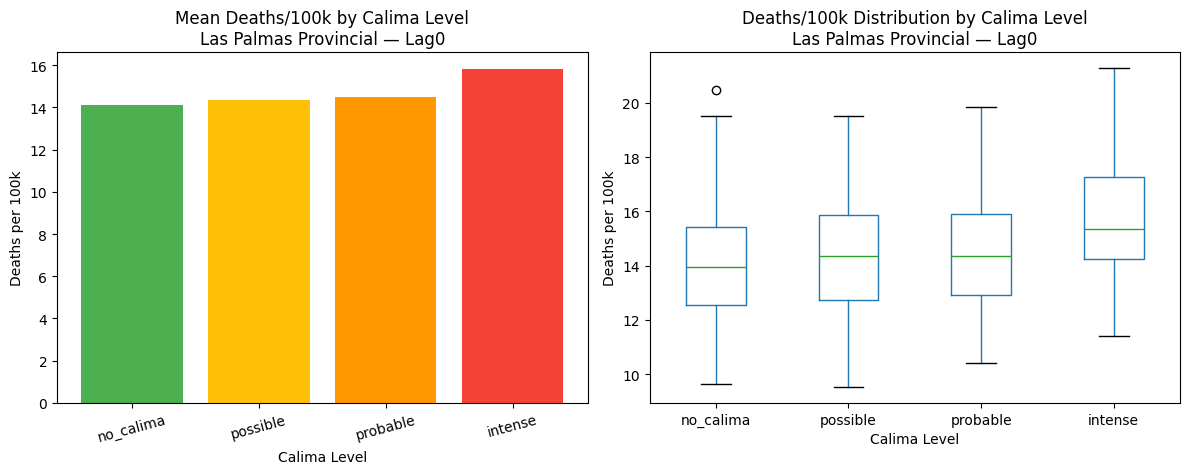

✓ Saved


In [163]:
# ── Figure: deaths/100k by calima level (provincial) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Means by level
means = df_gc.groupby('calima_level_provincial')['deaths_per_100k'].mean().reindex(level_order)

# Left: bar chart
axes[0].bar(level_order, means.values, color=['#4CAF50','#FFC107','#FF9800','#F44336'])
axes[0].set_title('Mean Deaths/100k by Calima Level\nLas Palmas Provincial — Lag0')
axes[0].set_xlabel('Calima Level')
axes[0].set_ylabel('Deaths per 100k')
axes[0].tick_params(axis='x', rotation=15)

# Right: boxplot
df_plot = df_gc[df_gc['calima_level_provincial'].isin(level_order)].copy()
df_plot['calima_level_provincial'] = pd.Categorical(
    df_plot['calima_level_provincial'], categories=level_order, ordered=True
)
df_plot.boxplot(column='deaths_per_100k', by='calima_level_provincial',
                ax=axes[1], grid=False)
axes[1].set_title('Deaths/100k Distribution by Calima Level\nLas Palmas Provincial — Lag0')
axes[1].set_xlabel('Calima Level')
axes[1].set_ylabel('Deaths per 100k')
plt.suptitle('')

plt.tight_layout()
plt.savefig(FIGURES / 'deaths_by_calima_level_las_palmas_provincial.png', dpi=150)
plt.show()
print("✓ Saved")

 # 5 Summary

In [164]:
# ── Summary table ──────────────────────────────────────────────────────────
summary = df_gc.groupby('calima_level_provincial')['deaths_per_100k'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std'
).reindex(level_order).round(3)

summary.index.name = 'calima_level'
print("=== Las Palmas Provincial — Deaths/100k by Calima Level ===\n")
print(summary.to_string())

print("\n=== Effect Size Summary ===")
print(f"{'Metric':<25} {'Provincial':>12} {'Insular GC':>12} {'Δ':>10}")
print("-" * 62)
print(f"{'η² (ANOVA, Lag0)':<25} {eta0_gc:>12.4f} {eta_gc:>12.4f} {eta0_gc- eta_gc:>+10.4f}")
print(f"{'η² (ANOVA, Lag2)':<25} {eta2:>12.4f} {'—':>12} {'—':>10}")
print(f"{'F-statistic (Lag0)':<25} {f0:>12.4f} {f_gc:>12.4f} {'—':>10}")
print(f"{'p-value (Lag0)':<25} {p0:>12.6f} {'0.000002':>12} {'—':>10}")

print("\n=== Decision Point ===")
print(f"η² provincial ({eta0_gc:.4f}) ≈ η² insular ({eta_gc:.4f}) — Δ = {eta0_gc- eta_gc:+.4f}")
print("✅ Signal maintained at provincial level — Phase 4 NOT blocked")


=== Las Palmas Provincial — Deaths/100k by Calima Level ===

                n    mean  median    std
calima_level                            
no_calima     284  14.100  13.936  1.998
possible      129  14.338  14.337  2.115
probable       63  14.506  14.337  2.247
intense        46  15.829  15.361  2.526

=== Effect Size Summary ===
Metric                      Provincial   Insular GC          Δ
--------------------------------------------------------------
η² (ANOVA, Lag0)                0.0495       0.0576    -0.0081
η² (ANOVA, Lag2)                0.0437            —          —
F-statistic (Lag0)              8.9943      10.5491          —
p-value (Lag0)                0.000008     0.000002          —

=== Decision Point ===
η² provincial (0.0495) ≈ η² insular (0.0576) — Δ = -0.0081
✅ Signal maintained at provincial level — Phase 4 NOT blocked


In [165]:
print(f"""## Interpretación Provincial

Ambas provincias replican la señal calima→mortalidad observada a nivel insular,
con efecto pequeño-moderado según los umbrales estándar (η² ~0.06 = medium).

| Provincia     | η² provincial | η² insular ref | Δ       | Decisión        |
|---------------|---------------|----------------|---------|-----------------|
| SC Tenerife   | {eta0_tf:.4f}  | {eta_tfe:.4f} (TFE) | {eta0_tf-eta_tfe:+.4f} | ✅ No bloqueada |
| Las Palmas    | {eta0_gc:.4f}  | {eta_gc:.4f} (GC)   | {eta0_gc-eta_gc:+.4f} | ✅ No bloqueada |

**Caída provincial:** La agregación de islas menores reduce ligeramente el η²
respecto a la isla dominante — dilución geográfica esperada, no un artefacto.

**Lag2:** Señal significativa en ambas provincias (p < 0.001), confirmando
efecto calima→mortalidad con retraso de ~2 semanas.

**Conclusión:** Análisis provincial consistente con el insular. Phase 4 no bloqueada.
""")

## Interpretación Provincial

Ambas provincias replican la señal calima→mortalidad observada a nivel insular,
con efecto pequeño-moderado según los umbrales estándar (η² ~0.06 = medium).

| Provincia     | η² provincial | η² insular ref | Δ       | Decisión        |
|---------------|---------------|----------------|---------|-----------------|
| SC Tenerife   | 0.0563  | 0.0541 (TFE) | +0.0023 | ✅ No bloqueada |
| Las Palmas    | 0.0495  | 0.0576 (GC)   | -0.0081 | ✅ No bloqueada |

**Caída provincial:** La agregación de islas menores reduce ligeramente el η²
respecto a la isla dominante — dilución geográfica esperada, no un artefacto.

**Lag2:** Señal significativa en ambas provincias (p < 0.001), confirmando
efecto calima→mortalidad con retraso de ~2 semanas.

**Conclusión:** Análisis provincial consistente con el insular. Phase 4 no bloqueada.

